# Diffusion of resonances by subhaloes — with differential (tidal) forces

A copy of `diffusion_version2.ipynb`. The only change to the physics is an optional differential-force treatment of the subhalo kicks (`force='tidal'` in `diffusion_coefficient` / `diffusion_timescale`; default `'fixed'` reproduces the original). Figs. 10 and 11 and the Hernquist/Plummer comparison now overlay both treatments: faint lines for the fixed centre, solid lines for the differential force. A diagnostic figure is added at the end. Axis limits in the two main figures now adapt to the data, and the annotations in the $\Delta I$ panel are rescaled to the resonance width. The width line is now labelled $2\Delta I_{\rm half}$, which is what `resonance_action` returns.

**Update:** the tidal correction now uses the full anisotropic (Fisher-weighted) encounter geometry by default (`TIDAL_GEOMETRY='aniso'`); set `TIDAL_GEOMETRY='iso'` to recover the isotropic approximation.

In [1]:
import os
import shutil
if os.path.isdir("/Library/TeX/texbin"):                         # TeX Live on macOS
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib import rcParams
from math import sqrt, pi
from scipy.integrate import quad

rcParams.update({
    "text.usetex": shutil.which("latex") is not None,  # Use LaTeX for text (mathtext if LaTeX is not installed)
    "font.family": "serif",            # Use serif fonts
    "font.serif": ["Computer Modern"], # Default LaTeX font
    "axes.labelsize": 14,              # Axis label size
    "font.size": 13,                   # General font size
    "legend.fontsize": 12,             # Legend font size
    "xtick.labelsize": 12,             # X tick label size
    "ytick.labelsize": 12,             # Y tick label size
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}"  # Optional packages
})

from scipy.special import gamma, gammainc
from scipy.integrate import quad
from scipy.special import hyp2f1

from dataclasses import dataclass

In [3]:
def langevin(a):
    a = np.asarray(a)
    out = np.empty_like(a, dtype=float)
    small = np.abs(a) < 1e-3

    # small-a expansion: L(a) ~ a/3 - a^3/45 + ...
    out[small] = a[small] / 3.0 * (1.0 - a[small]**2/15.0)

    # general case: L(a) = coth(a) - 1/a
    aa = a[~small]
    out[~small] = 1.0/np.tanh(aa) - 1.0/aa
    return out

In [4]:
def L_over_a(a):
    a = np.asarray(a)
    small = np.abs(a) < 1e-3
    out = np.empty_like(a, dtype=float)

    # For small a, L(a)/a -> 1/3 - a^2/45 + ...
    out[small] = 1.0/3.0 * (1.0 - a[small]**2/15.0)

    aa = a[~small]
    out[~small] = langevin(aa) / aa
    return out

In [5]:
# Constants & fiducial parameters
G = 4.302e-6  # kpc (km/s)^2 / Msun
sigma = 200   # km/s, subhalo velocity dispersion (typical)
V0 = 230      # km/s, characteristic circular speed

alpha  = 1.9
M0     = 2.52e7
A      = 3.26e-5

In [6]:
def J_vs_sigma(v_star, sigma):
    prefac = 1.0 / (sqrt(2.0*pi) * sigma * v_star)

    def integrand(u):
        a = u * v_star / sigma**2
        gauss_part = np.exp(-(u - v_star)**2 / (2.0 * sigma**2)) \
                   - np.exp(-(u + v_star)**2 / (2.0 * sigma**2))
        return gauss_part * L_over_a(a)

    # Truncate at some finite upper limit where the Gaussians are tiny
    u_max = v_star + 6.0 * sigma
    val, err = quad(integrand, 0.0, u_max, epsabs=1e-8, epsrel=1e-6)
    return prefac * val

In [7]:
# --- Aquarius Einasto parameters ---
alpha_E = 0.678
r200 = 210.0       # kpc
r_minus2 = 0.81 * r200

# --- Normalization constant ---
x200 = (2.0 / alpha_E) * (r200 / r_minus2)**alpha_E
s = 3.0 / alpha_E
N = (4 * np.pi * r_minus2**3 * np.exp(2/alpha_E)
     * (alpha_E/2)**(3/alpha_E) / alpha_E
     * gamma(s) * gammainc(s, x200))

def P(r):
    """Normalized Aquarius Einasto number-density profile (1/kpc^3)."""
    rho = np.exp(- (2/alpha_E) * ((r / r_minus2)**alpha_E - 1.0))
    return rho / N

In [8]:
def mass_integral(M_min, M_max, M0, alpha, A, B0):
    """
    Approximate value of:
        I = ∫_{M_min}^{M_max} dM (dN/dM) M^2 * B(M)
    with:
        dN/dM = A * (M / M0)^(-alpha)
        B(M) ≈ B0 - ln(M)

    So:
        I ≈ A * M0**alpha * ∫ M^{2 - alpha} [B0 - ln M] dM
    """

    # exponent 3 - alpha appears in the antiderivative
    p = 3.0 - alpha

    def F(M):
        # Antiderivative of M^{2 - alpha} (B0 - ln M)
        # F(M) = M^p * [ (B0 - ln M)/p + 1/p^2 ]
        return M**p * ((B0 - np.log(M)) / p + 1.0 / p**2)

    I = A * M0**alpha * (F(M_max) - F(M_min))
    return I


In [9]:
def M_hm(mass_particle, h):
    return 1e10 * (1/h) * (mass_particle / 1.0)**(-3.33)

def S_mass(M, mass_particle):
    """
    Suppression factor:
        S(M) = (1 + mass_cut / M)^(-1)
    """
    return (1.0 + M_hm(mass_particle, h=0.7) / M)**(-1.)


def dNdM(M, M0, alpha, A):
    """
    Mass function:
        dN/dM = A * (M / M0)^(-alpha)
    """
    return A * (M / M0)**(-alpha)


def B_of_M_approx(M, B0):
    """
    Approximate B(M) using:
        B(M) ≈ B0 - ln(M)
    where B0 is treated as a constant parameter.
    """
    return B0 - np.log(M)


def mass_integrand(M, M0, alpha, A, B0, mass_cut):
    """
    Integrand for the mass part of D_II:
        integrand = (dN/dM) * M^2 * B(M) * S(M)
    with:
        dN/dM = A * (M / M0)^(-alpha)
        B(M) ≈ B0 - ln(M)
        S(M) = (1 + mass_cut / M)^(-1)
    """
    return dNdM(M, M0, alpha, A) * M**2 * B_of_M_approx(M, B0) * S_mass(M, mass_cut)


def mass_integral_quad(M_min, M_max, M0, alpha, A, B0, mass_cut):
    """
    Numerically evaluate:
        I = ∫_{M_min}^{M_max} dM (dN/dM) M^2 B(M) S(M)
    using scipy.integrate.quad.
    """
    I, err = quad(
        mass_integrand,
        M_min,
        M_max,
        args=(M0, alpha, A, B0, mass_cut),
        epsabs=0,
        epsrel=1e-5,
        limit=200
    )
    return I  # you can also return (I, err) if you care about the error

In [10]:
def resonance_action(m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar):

    n       = n_resonance
    m       = m_resonance
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = m*np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    #epsilon = f_bar * V0**2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2
    epsilon = f_bar * ((R_res + R_bar)**5/(R_res**2))*(V0**2)/2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_half = 2 * np.sqrt(4*epsilon / alpha)
    #Delta_I_half = np.sqrt(4*epsilon / alpha)

    return Delta_I_half

                             # full width, as used in t_diff

In [11]:
o_p = 40

width_il = resonance_action(2, -1, o_p, 1.6, 0.02)
width_20 = resonance_action(2, 0, o_p, 1.6, 0.02)
width_21 = resonance_action(2, 1, o_p, 1.6, 0.02)
width_22 = resonance_action(2, 2, o_p, 1.6, 0.02)
width_23 = resonance_action(2, 3, o_p, 1.6, 0.02)
print(width_il/width_20)
print(width_20/width_20)
print(width_21/width_20)
print(width_22/width_20)
print(width_23/width_20)

0.541196100146197
1.0
1.3065629648763764
1.5537739740300374
1.7667258824049765


In [12]:
kappa = (0.01*1.62)**2 * 1e-8
bmax  = 210
B_P   = np.log(bmax**2/kappa) - 1
print(B_P)

36.3603838788749


## Differential (tidal) forces, with the anisotropic encounter geometry

**1. Relative kick.** The actions are defined relative to the centre of the host potential. A subhalo accelerates the star **and** the host mass that sets the star's orbit, so the kick that changes $L_z$ is the *relative* impulse

$$\Delta\mathbf v_{\rm rel} = \mathbf f(\mathbf b) - \big\langle \mathbf f\big((\mathbf b + \mathbf x_* - \mathbf y)_\perp\big)\big\rangle_{\mathbf y},\qquad
\mathbf f(\mathbf b)=\frac{2GM}{u}\,\frac{\mathbf b}{b^2+r_s^2}.$$

Here $\perp$ is the projection onto the encounter plane (perpendicular to $\hat{\mathbf u}$). The average is over the host mass enclosed by the orbit, $|\mathbf y|<R_{\rm res}$; by the shell theorem, mass outside exerts no net force on the star. For the logarithmic halo $dM\propto dr$, so $|\mathbf y|$ is sampled uniformly in $[0,R_{\rm res}]$ with isotropic directions.

**2. Kernel for each direction.** For each direction $\hat{\mathbf u}$ of the relative velocity, integrate over the encounter plane:

$$S_{\rm fix}(\hat{\mathbf u};M)=\int d^2b\,\frac{(\mathbf e_\varphi\cdot\mathbf b)^2}{(b^2+r_s^2)^2},\qquad
S_{\rm tid}(\hat{\mathbf u};M)=\int d^2b\,\Big[\mathbf e_\varphi\cdot\tfrac{u}{2GM}\Delta\mathbf v_{\rm rel}\Big]^2 .$$

**3. Anisotropic weighting.** The relative-velocity directions follow the Fisher distribution $f(\hat{\mathbf u}\,|\,u)\propto e^{\xi\,\mathbf e_\varphi\cdot\hat{\mathbf u}}$ with $\xi=uv_*/\sigma^2$ (Eq. 56). $S(\hat{\mathbf u})=S(-\hat{\mathbf u})$, so the sign of the axis does not matter. The paper's fixed-centre result is exactly separable, $\langle S_{\rm fix}\rangle_\xi = 3\lambda(\xi)\,\overline{S}_{\rm fix}$, and this is printed as a check. The tidal kernel is **not** separable, because the projected star–centre offset $d=R_{\rm res}\sqrt{1-(\hat{\mathbf x}\cdot\hat{\mathbf u})^2}$ depends on $\hat{\mathbf u}$. The velocity-weighted correction is therefore

$$C(M)=\frac{\int du\,\frac{f(u)}{u}\,\langle S_{\rm tid}\rangle_{\xi(u)}}{\int du\,\frac{f(u)}{u}\,\langle S_{\rm fix}\rangle_{\xi(u)}},\qquad
\mathcal B_{\rm tid}(M)=\mathcal B(M)\,C(M).$$

This gives exactly $D_{II}^{\rm tid}$ when it replaces $\mathcal B$ in Eq. 68, with `J_vs_sigma` left unchanged. `TIDAL_GEOMETRY='iso'` instead uses $\mathcal B_{\rm tid}=\frac{3}{\pi}\overline{S}_{\rm tid}$, the isotropic approximation.

**Limits.**
* $b\gg R_{\rm res}$: $|\Delta\mathbf v_{\rm rel}|\simeq 2GMd/(ub^2)$, so the Coulomb logarithm is cut at $b_{\rm eff}\sim R_{\rm res}$ instead of $b_{\max}=210$ kpc.
* $r_s\gtrsim R_{\rm res}$: star and inner galaxy move together, and $\mathcal B_{\rm tid}\approx0.2\,(R_{\rm res}/r_s)^2$.

**Notes.**
* `kappa_rs` is derived from the same `B0` as the fixed-centre curve, so each fixed/tidal pair uses identical subhaloes.
* `type='P'` inherits `kappa` with its extra factor 0.01 ($B_P=36.36$).
* The per-direction table is cached (`tidalS_*.npz`), so the kernel runs once per $(R_{\rm res},\kappa)$ (about 1–2 min). The $\sigma$-dependent weighting is recomputed each time and takes a fraction of a second.


In [13]:
import os
from scipy.interpolate import interp1d
_trapz = getattr(np, "trapezoid", None) or np.trapz   # numpy>=2 compatibility

TIDAL_GEOMETRY = 'aniso'     # 'aniso' (Fisher-weighted directions, default) or 'iso'

def _fib_sphere(n):
    i  = np.arange(n) + 0.5
    th = np.arccos(1 - 2*i/n); ph = np.pi*(1 + 5**0.5)*i
    return np.stack([np.sin(th)*np.cos(ph), np.sin(th)*np.sin(ph), np.cos(th)], 1)

def tidal_S_table(R_star, kappa_rs, logM_grid=np.linspace(2.5, 11.5, 37), b_max=210.,
                  n_dir=600, n_b=260, n_psi=40, n_centre=40, seed=1, cache=True):
    """
    Per-direction kernels S_fix(u_hat; M) and S_tid(u_hat; M)  [shape (n_dir, n_M)].
    Plummer-form kick, r_s^2 = kappa_rs*M.  Star at R_star*xhat, e_phi = yhat.
    S_tid uses the kick relative to the host mass enclosed by the orbit (|y|<R_star, dM ∝ dr).
    """
    fname = f"../data/tidalS_R{R_star:.3f}_k{kappa_rs:.3e}_n{n_dir}.npz"
    if cache and os.path.exists(fname):
        d = np.load(fname)
        if d["logM"].shape == logM_grid.shape and np.allclose(d["logM"], logM_grid):
            return 10**d["logM"], d["U"], d["S_fix"], d["S_tid"]
    Ms  = 10**logM_grid; rs2 = kappa_rs*Ms
    lnb = np.linspace(np.log(1e-3*np.sqrt(rs2.min())), np.log(b_max), n_b); b = np.exp(lnb)
    psi = np.linspace(0, 2*np.pi, n_psi, endpoint=False); dpsi = psi[1] - psi[0]
    xhat, ephi = np.array([1., 0, 0]), np.array([0, 1., 0])
    rng = np.random.default_rng(seed)
    Y   = ((np.arange(n_centre) + 0.5)/n_centre*R_star)[:, None] * _fib_sphere(n_centre)[rng.permutation(n_centre)]
    U   = _fib_sphere(n_dir)
    S_fix = np.zeros((n_dir, len(Ms))); S_tid = np.zeros_like(S_fix)
    w = (b**2)[None, :, None]                                   # d^2b = b^2 dln b dpsi
    for k, uh in enumerate(U):
        ref = np.array([0, 0, 1.]) if abs(uh[2]) < 0.9 else np.array([1., 0, 0])
        p = np.cross(uh, ref); p /= np.linalg.norm(p); q = np.cross(uh, p)
        perp = lambda v: v - (v @ uh)[..., None]*uh
        bv = b[:, None, None]*(np.cos(psi)[None, :, None]*p + np.sin(psi)[None, :, None]*q)
        X  = R_star*xhat + bv                                   # subhalo position at closest approach to star
        gs = (bv @ ephi)[None] / ((bv**2).sum(-1)[None] + rs2[:, None, None])
        gc = np.zeros_like(gs)
        for y in Y:                                             # mass-weighted kick on the enclosed host mass
            By = perp(X - y)
            gc += (By @ ephi)[None] / ((By**2).sum(-1)[None] + rs2[:, None, None])
        gc /= n_centre
        S_fix[k] = _trapz(((gs**2)*w).sum(-1)*dpsi, lnb, axis=1)
        S_tid[k] = _trapz((((gs - gc)**2)*w).sum(-1)*dpsi, lnb, axis=1)
    if cache: np.savez(fname, logM=logM_grid, U=U, S_fix=S_fix, S_tid=S_tid)
    return Ms, U, S_fix, S_tid

def _f_u(u, sig, vstar):
    """Relative-speed distribution f(u), Eq. 53 / B5."""
    return u/(sig*vstar*np.sqrt(2*np.pi))*(np.exp(-(u - vstar)**2/(2*sig**2)) - np.exp(-(u + vstar)**2/(2*sig**2)))

def _fisher_weights(U, xi):
    """Fisher (von Mises-Fisher) weights of the direction grid about e_phi; S(u)=S(-u) so the sign is irrelevant."""
    mu = U[:, 1]                                                # e_phi . u_hat
    wts = np.exp(-xi*(mu + 1.0)) if xi > 0 else np.ones(len(U)) # shifted exponent: no overflow
    return wts/wts.sum()

def aniso_correction(U, S_fix, S_tid, sig, vstar, n_u=400):
    """C(M) = ∫du f/u <S_tid>_xi / ∫du f/u <S_fix>_xi,  xi = u v*/sigma^2."""
    ug = np.linspace(1e-3, vstar + 7*sig, n_u); wu = _f_u(ug, sig, vstar)/ug
    num = np.zeros(S_fix.shape[1]); den = np.zeros(S_fix.shape[1])
    for ui, w_ in zip(ug, wu):
        W = _fisher_weights(U, ui*vstar/sig**2)
        num += w_*(W @ S_tid); den += w_*(W @ S_fix)
    return num/den

_B_tid_cache = {}
def B_tidal_func(R_res, B0, geometry=None, sig=None, vstar=None):
    """Interpolant M -> B_tid(M) for resonance radius R_res, with r_s set by the same B0 as the fixed curve."""
    geometry = TIDAL_GEOMETRY if geometry is None else geometry
    sig   = sigma if sig is None else sig
    vstar = V0    if vstar is None else vstar
    key = (round(R_res, 4), round(B0, 4), geometry, sig, vstar)
    if key not in _B_tid_cache:
        kappa_rs = bmax**2 * np.exp(-(B0 + 1))                  # inverts B0 = ln(bmax^2/kappa) - 1
        Ms, U, Sf, St = tidal_S_table(R_res, kappa_rs)
        B_fix_num = 3/np.pi*Sf.mean(0)
        chk = np.max(np.abs(B_fix_num - (B0 - np.log(Ms)))[Ms < 1e9])
        xi_t = 2.0; sep = (_fisher_weights(U, xi_t) @ Sf)[0]/Sf.mean(0)[0]
        if geometry == 'aniso':
            C  = aniso_correction(U, Sf, St, sig, vstar)
            Bt = B_fix_num*C
        elif geometry == 'iso':
            C  = St.mean(0)/Sf.mean(0)
            Bt = 3/np.pi*St.mean(0)
        else:
            raise ValueError("geometry must be 'aniso' or 'iso'")
        print(f"[tidal kernel] R_res={R_res:.3f} kpc, B0={B0:.2f}, {geometry}, sigma={sig}: "
              f"max|B_fix(num) - (B0 - ln M)| = {chk:.3f};  <S_fix>_xi=2 / iso = {sep:.4f} (3*lambda = {3*L_over_a(np.array([xi_t]))[0]:.4f})")
        f = interp1d(np.log(Ms), np.log(Bt), kind='linear', fill_value='extrapolate')
        _B_tid_cache[key] = lambda M, f=f: np.exp(f(np.log(M)))
        _B_tid_cache[key + ('C',)] = (Ms, C)
    return _B_tid_cache[key]

def mass_integral_quad_B(M_min, M_max, M0, alpha, A, B_func, mass_cut):
    """As mass_integral_quad, but with an arbitrary geometric factor B_func(M)."""
    f   = lambda M: dNdM(M, M0, alpha, A) * M**2 * B_func(M) * S_mass(M, mass_cut)
    pts = [10.**k for k in range(3, 12) if M_min < 10.**k < M_max]
    I, err = quad(f, M_min, M_max, epsabs=0, epsrel=1e-5, limit=400, points=pts or None)
    return I


In [14]:
def diffusion_coefficient(m_resonance, n_resonance, pattern_speed, mass_min, mass_max, mass_cut, impact_max, type, f_sup, force='fixed'):
    results = []
    for mass_max_i in np.atleast_1d(mass_max):
        b_max   = impact_max
        n       = n_resonance
        m       = m_resonance
        omega_p = pattern_speed

        # b-min
        m_min = 10**mass_min  # M_sun
        m_max = 10**mass_max_i  # M_sun

        R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

        # B term
        if type == 'P':
            #mass_int = mass_integral(m_min, m_max, M0, alpha, A, B0=27.15)
            B0_type = B_P
        if type == 'H':
            #mass_int = mass_integral(m_min, m_max, M0, alpha, A, B0=28.02)
            B0_type = 28.02

        if force == 'fixed':      # galactic centre held fixed (as in the submitted paper)
            mass_int = mass_integral_quad(m_min, m_max, M0, alpha, A, B0=B0_type, mass_cut=mass_cut)
        elif force == 'tidal':    # kick relative to the host mass enclosed by the orbit
            mass_int = mass_integral_quad_B(m_min, m_max, M0, alpha, A,
                                            B_func=B_tidal_func(R_res, B0_type), mass_cut=mass_cut)
        else:
            raise ValueError("force must be 'fixed' or 'tidal'")
        P_res = P(R_res)

        # Pre-factor
        prefactor = 2*np.pi * G**2 * (R_res/m)**2

        D = prefactor*mass_int*P_res*J_vs_sigma(V0, sigma)
        results.append(D)

    return np.array(results)


def diffusion_timescale(m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar, mass_min, mass_max, mass_cut, impact_max, type, f_sup, force='fixed'):

    n       = n_resonance
    m       = m_resonance
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = m*np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    #epsilon = f_bar * V0**2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2
    epsilon = f_bar * ((R_res + R_bar)**5/(R_res**2)) * (V0**2)/2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_half = 2 * np.sqrt(4*epsilon / alpha)

    t_diff = (Delta_I_half)**2 / (2*diffusion_coefficient(m_resonance, n_resonance, pattern_speed, mass_min, mass_max, mass_cut, impact_max, type, f_sup, force=force))
    t_lib  = (2*np.pi)/np.sqrt(alpha*epsilon)

    #print(f't_diff = {t_diff}')

    print(epsilon)

    return [t_diff, (4/np.pi)*(t_lib/t_diff)]

    

In [15]:
M = np.linspace(5, 11, 100)

D_list_cdm     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, 
                                       mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='H', f_sup=1.0)
delta_list_cdm = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, 
                    mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='H', f_sup=1.0)

D_list_wdm1     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, 
                                        mass_min=3, mass_max=M, mass_cut=5, impact_max=200, type='H', f_sup=1.0)
delta_list_wdm1 = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, 
                    mass_min=3, mass_max=M, mass_cut=5, impact_max=200, type='H', f_sup=1.0)

D_list_wdm2     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, 
                                        mass_min=3, mass_max=M, mass_cut=3, impact_max=200, type='H', f_sup=1.0)
delta_list_wdm2 = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, 
                    mass_min=3, mass_max=M, mass_cut=3, impact_max=200, type='H', f_sup=1.0)

DeltaI_t8_cdm  = np.sqrt(2*D_list_cdm*8)
DeltaI_t8_wdm1 = np.sqrt(2*D_list_wdm1*8)
DeltaI_t8_wdm2 = np.sqrt(2*D_list_wdm2*8)

# --- same three dark matter models, with kicks relative to the host (differential forces) ---
kw = dict(m_resonance=2, n_resonance=0, pattern_speed=40, mass_min=3, mass_max=M, impact_max=200, type='H', f_sup=1.0, force='tidal')
kt = dict(radius_bar=1.6, strength_bar=0.02, **kw)
D_list_cdm_tid  = diffusion_coefficient(mass_cut=100, **kw);  delta_list_cdm_tid  = diffusion_timescale(mass_cut=100, **kt)
D_list_wdm1_tid = diffusion_coefficient(mass_cut=5,   **kw);  delta_list_wdm1_tid = diffusion_timescale(mass_cut=5,   **kt)
D_list_wdm2_tid = diffusion_coefficient(mass_cut=3,   **kw);  delta_list_wdm2_tid = diffusion_timescale(mass_cut=3,   **kt)

DeltaI_t8_cdm_tid  = np.sqrt(2*D_list_cdm_tid*8)
DeltaI_t8_wdm1_tid = np.sqrt(2*D_list_wdm1_tid*8)
DeltaI_t8_wdm2_tid = np.sqrt(2*D_list_wdm2_tid*8)


529.0
529.0


529.0


[tidal kernel] R_res=5.750 kpc, B0=28.02, aniso, sigma=200: max|B_fix(num) - (B0 - ln M)| = 0.000;  <S_fix>_xi=2 / iso = 0.8060 (3*lambda = 0.8060)


529.0


529.0


529.0


In [16]:
def M_hm(m_wdm, h):
    return 1e10 * (1/h) * (m_wdm / 1.0)**(-3.33)  # M_sun/h

def S_wdm(mass, m_particle):
    mass_cut = M_hm(m_wdm=m_particle, h=0.7)
    return (1 + (mass_cut/mass))**(-1.3)

In [17]:
from matplotlib.lines import Line2D

def _vis(x, *arrays, xlim=(1e5, 1e10)):   # match the x-range of the plots
    """Positive values of arrays inside the plotted x-range (for axis limits)."""
    m = (x >= xlim[0]) & (x <= xlim[1])
    v = np.concatenate([np.atleast_1d(a)[m] for a in arrays])
    return v[np.isfinite(v) & (v > 0)]

force_legend = [Line2D([], [], color='k', lw=1.5, label=r'relative to host (differential force)'),
                Line2D([], [], color='k', lw=1.5, alpha=0.3, label=r'fixed galactic centre')]


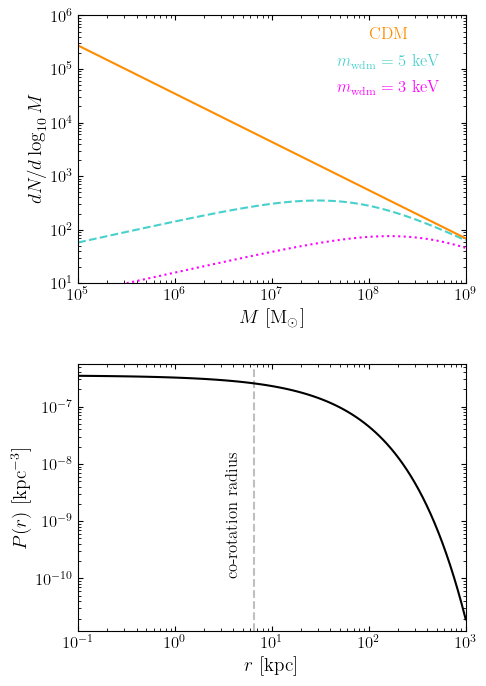

In [18]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 8),
    gridspec_kw={'hspace': 0.3}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)

M_vals = np.logspace(5,9,100)
dndm = A*(M_vals/M0)**(-alpha)
ax1.plot(M_vals, S_wdm(M_vals, 3)*np.log(10)*M_vals*dndm, color='magenta', linestyle=':')
ax1.plot(M_vals, S_wdm(M_vals, 5)*np.log(10)*M_vals*dndm, color='mediumturquoise', linestyle='--')
ax1.plot(M_vals, np.log(10)*M_vals*dndm, color='darkorange')
ax1.set_xlabel(r'$M$ [M$_{\odot}$]')
ax1.set_ylabel(r'$dN / d \log_{10} M$')

r = np.logspace(-1,3,100)
ax2.plot(r, P(r), color='k')
ax2.set_xlabel('$r$ [kpc]')
ax2.set_ylabel('$P(r)$ [kpc$^{-3}$]')

ax2.axvline(V0/35, color='k', linestyle='--', alpha=0.25)
ax2.text(
    10**0.6, 1e-10,                        
    'co-rotation radius',       # text
    ha='center', va='bottom',        
    fontsize=12, color='k',           
    rotation='vertical'
)

ax1.text(
    0.8, 0.9,                        
    r'CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='darkorange',           
)
ax1.text(
    0.8, 0.8,                        
    r'$m_{\rm wdm} = 5$ keV',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='mediumturquoise',           
)
ax1.text(
    0.8, 0.70,                        
    r'$m_{\rm wdm} = 3$ keV',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='magenta',           
)

ax1.set_xlim(10**5, 10**9)
ax1.set_ylim(10, 10**6)
ax2.set_xlim(10**-1, 10**3)

#plt.savefig('../figures/dark_matter_properties.pdf', dpi=400, bbox_inches='tight')
plt.show()

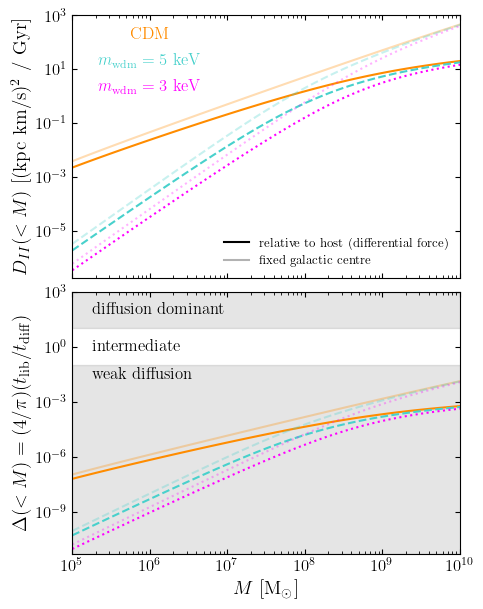

In [19]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 7), sharex=True,
    gridspec_kw={'hspace': 0.05}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)
    axis.set_xlim(1e5,1e10)

models = [(D_list_cdm,  delta_list_cdm,  D_list_cdm_tid,  delta_list_cdm_tid,  'darkorange',      '-'),
          (D_list_wdm1, delta_list_wdm1, D_list_wdm1_tid, delta_list_wdm1_tid, 'mediumturquoise', '--'),
          (D_list_wdm2, delta_list_wdm2, D_list_wdm2_tid, delta_list_wdm2_tid, 'magenta',         ':')]

for D_f, dl_f, D_t, dl_t, col, ls in models:
    ax1.plot(10**M, D_f,   color=col, linestyle=ls, alpha=0.3)   # fixed centre
    ax1.plot(10**M, D_t,   color=col, linestyle=ls)              # differential force
    ax2.plot(10**M, dl_f[1], color=col, linestyle=ls, alpha=0.3)
    ax2.plot(10**M, dl_t[1], color=col, linestyle=ls)

ax1.set_ylabel(r'$D_{II} (<M)$ [(kpc km/s)$^2$ / Gyr]')
ax2.set_ylabel(r'$\Delta(<M) = (4/\pi)(t_{\rm lib} / t_{\rm diff})$')
ax2.set_xlabel(r'$M$ [M$_{\odot}$]')

ax1.text(0.2, 0.9,  r'CDM', transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='darkorange')
ax1.text(0.2, 0.8,  r'$m_{\rm wdm} = 5$ keV', transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='mediumturquoise')
ax1.text(0.2, 0.70, r'$m_{\rm wdm} = 3$ keV', transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='magenta')
ax1.legend(handles=force_legend, loc='lower right', fontsize=9, frameon=False)

vD = _vis(10**M, *[m_[0] for m_ in models], *[m_[2] for m_ in models])
ax1.set_ylim(min(1e-5, 0.5*vD.min()), max(1e3, 2*vD.max()))

vd = _vis(10**M, *[m_[1][1] for m_ in models], *[m_[3][1] for m_ in models])
lo, hi = min(1e-3, 0.5*vd.min()), max(1e3, 2*vd.max())
ax2.set_ylim(lo, hi)
ax2.fill_between(x=10**M, y1=10, y2=hi, color='k', alpha=0.1)
ax2.fill_between(x=10**M, y1=lo, y2=0.1, color='k', alpha=0.1)
# band labels placed in data coordinates (y) so they stay inside their bands for any axis range
ax2.text(0.05, np.sqrt(10*hi), r'diffusion dominant', transform=ax2.get_yaxis_transform(), ha='left', va='center', fontsize=12, color='k')
ax2.text(0.05, 1.0,            r'intermediate',       transform=ax2.get_yaxis_transform(), ha='left', va='center', fontsize=12, color='k')
ax2.text(0.05, 0.03,           r'weak diffusion',     transform=ax2.get_yaxis_transform(), ha='left', va='center', fontsize=12, color='k')

#plt.savefig('../figures/diffusion_results_tidal.pdf', dpi=400, bbox_inches='tight')
plt.show()


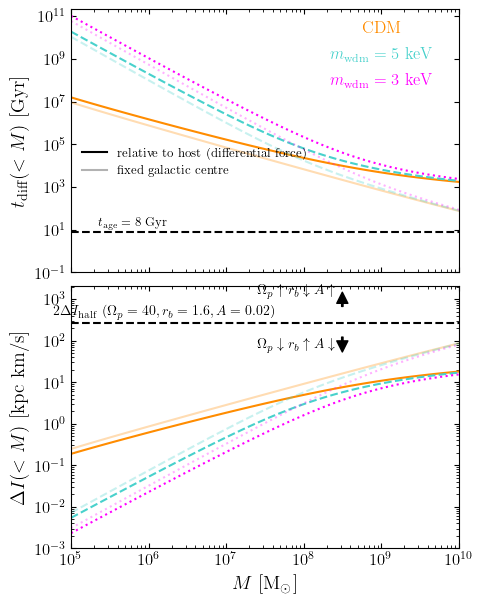

In [20]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 7), sharex=True,
    gridspec_kw={'hspace': 0.05}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)
    axis.set_xlim(1e5,1e10)

tmodels = [(delta_list_cdm,  delta_list_cdm_tid,  DeltaI_t8_cdm,  DeltaI_t8_cdm_tid,  'darkorange',      '-'),
           (delta_list_wdm1, delta_list_wdm1_tid, DeltaI_t8_wdm1, DeltaI_t8_wdm1_tid, 'mediumturquoise', '--'),
           (delta_list_wdm2, delta_list_wdm2_tid, DeltaI_t8_wdm2, DeltaI_t8_wdm2_tid, 'magenta',         ':')]

for dl_f, dl_t, dI_f, dI_t, col, ls in tmodels:
    ax1.plot(10**M, dl_f[0], color=col, linestyle=ls, alpha=0.3)   # fixed centre
    ax1.plot(10**M, dl_t[0], color=col, linestyle=ls)              # differential force
    ax2.plot(10**M, dI_f,    color=col, linestyle=ls, alpha=0.3)
    ax2.plot(10**M, dI_t,    color=col, linestyle=ls)

ax1.set_ylabel(r'$t_{\rm diff}(<M)$ [Gyr]')
ax2.set_ylabel(r'$\Delta I(<M)$ [kpc km/s]')
ax2.set_xlabel(r'$M$ [M$_{\odot}$]')

vt = _vis(10**M, *[m_[0][0] for m_ in tmodels], *[m_[1][0] for m_ in tmodels])
ax1.set_ylim(min(1e-1, 0.5*vt.min()), max(1e4, 2*vt.max()))
ax1.axhline(8.0, linestyle='--', c='k')
ax1.text(10**5.8, 10, r'$t_{\rm age} = 8$ Gyr', ha='center', va='bottom', fontsize=9, color='k')

# full resonance width 2*Delta I_half (resonance_action returns the full width)
W = resonance_action(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02)
f = W/10.4   # annotation positions below were tuned for W = 10.4; rescale them
ax2.axhline(W, linestyle='--', color='k')
ax2.text(10**6.2, W*1.2, r'$2\Delta I_{\rm half}$ ($\Omega_p = 40, r_b = 1.6, A=0.02$)', ha='center', va='bottom', fontsize=10, color='k')
ax2.text(10**7.9, 40*f, r'$\Omega_p \uparrow r_b \downarrow A \uparrow$',   ha='center', va='bottom', fontsize=10, color='k')
ax2.text(10**7.9, 2*f,  r'$\Omega_p \downarrow r_b \uparrow A \downarrow$', ha='center', va='bottom', fontsize=10, color='k')
arrow = dict(facecolor='k', shrink=0.05, width=1, headwidth=8, headlength=8)
ax2.annotate('', xy=(10**8.5, 60*f), xytext=(10**8.5, 25*f), arrowprops=arrow)
ax2.annotate('', xy=(10**8.5, 2*f),  xytext=(10**8.5, 5*f),  arrowprops=arrow)

vI = _vis(10**M, *[m_[2] for m_ in tmodels], *[m_[3] for m_ in tmodels])
ax2.set_ylim(min(1e-3, 0.5*vI.min()), max(1e3, 8*W))

ax1.text(0.8, 0.9,  r'CDM', transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='darkorange')
ax1.text(0.8, 0.8,  r'$m_{\rm wdm} = 5$ keV', transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='mediumturquoise')
ax1.text(0.8, 0.70, r'$m_{\rm wdm} = 3$ keV', transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='magenta')
ax1.legend(handles=force_legend, loc='center left', bbox_to_anchor=(0.0, 0.42), fontsize=9, frameon=False)

#plt.savefig('../figures/timescale_results_tidal.pdf', dpi=400, bbox_inches='tight')
plt.show()


In [21]:
D_list_H     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, 
                                     mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='H', f_sup=1.0)
D_list_P     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, 
                                     mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='P', f_sup=1.0)


delta_list_H = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, 
                    mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='H', f_sup=1.0)
delta_list_P = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, 
                    mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='P', f_sup=1.0)
D_list_H_tid = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40,
                                     mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='H', f_sup=1.0, force='tidal')
D_list_P_tid = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40,
                                     mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='P', f_sup=1.0, force='tidal')


529.0
529.0


[tidal kernel] R_res=5.750 kpc, B0=36.36, aniso, sigma=200: max|B_fix(num) - (B0 - ln M)| = 0.000;  <S_fix>_xi=2 / iso = 0.8060 (3*lambda = 0.8060)


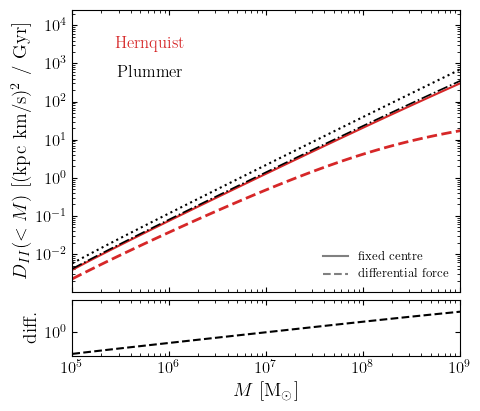

In [22]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 4.5), sharex=True,
    gridspec_kw={'hspace': 0.05, 'height_ratios': [5, 1]}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)
    axis.set_xlim(1e5,1e9)

M = np.linspace(5,10, 100)

ax1.set_ylabel(r'$D_{II} (<M)$ [(kpc km/s)$^2$ / Gyr]')
ax2.set_ylabel(r'diff.')
ax2.set_xlabel(r'$M$ [M$_{\odot}$]')

ax1.plot(10**M, D_list_H, color='tab:red')
ax1.plot(10**M, D_list_P, color='k', linestyle=':')

ax2.plot(10**M, D_list_H-D_list_P, color='k')
ax1.plot(10**M, D_list_H_tid, color='tab:red', linestyle='--', lw=2)
ax1.plot(10**M, D_list_P_tid, color='k', linestyle='-.', lw=1.2)
ax2.plot(10**M, np.abs(D_list_H_tid-D_list_P_tid), color='k', linestyle='--')
ax1.legend(handles=[Line2D([], [], color='gray', lw=1.5, label='fixed centre'),
                    Line2D([], [], color='gray', lw=1.5, ls='--', label='differential force')],
           loc='lower right', fontsize=9, frameon=False)

ax1.text(
    0.2, 0.85,                        
    r'Hernquist',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='tab:red',           
)
ax1.text(
    0.2, 0.75,                        
    r'Plummer',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='k',           
)

#plt.savefig('../figures/subhalo_type_compare.pdf', dpi=400, bbox_inches='tight')
plt.show()

In [23]:
D_list_f1     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, 
                                     mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='P', f_sup=1.0)
D_list_f2     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, 
                                     mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='P', f_sup=1e-10)


delta_list_f1 = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=4, strength_bar=0.02, 
                    mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='P', f_sup=1.0)
delta_list_f2 = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=4, strength_bar=0.02, 
                    mass_min=3, mass_max=M, mass_cut=100, impact_max=200, type='P', f_sup=1e-10)

529.0
529.0


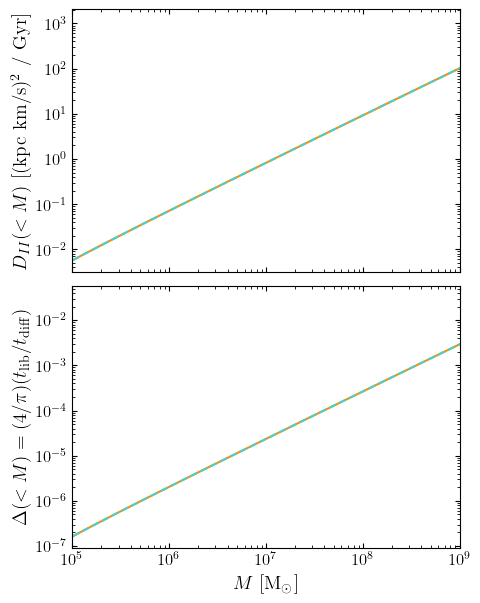

In [24]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 7), sharex=True,
    gridspec_kw={'hspace': 0.05}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)
    axis.set_xlim(1e5,1e9)

M = np.linspace(5,10, 100)

ax1.plot(10**M, D_list_f1, color='darkorange')
ax2.plot(10**M, delta_list_f1[1], color='darkorange')

ax1.plot(10**M, D_list_f2, color='mediumturquoise', linestyle='--')
ax2.plot(10**M, delta_list_f2[1], color='mediumturquoise', linestyle='--')

#ax1.plot(10**M, D_list_wdm2, color='magenta', linestyle=':')
#ax2.plot(10**M, delta_list_wdm2[1], color='magenta', linestyle=':')

ax1.set_ylabel(r'$D_{II} (<M)$ [(kpc km/s)$^2$ / Gyr]')
ax2.set_ylabel(r'$\Delta(<M) = (4/\pi)(t_{\rm lib} / t_{\rm diff})$')
ax2.set_xlabel(r'$M$ [M$_{\odot}$]')


#plt.savefig('../figures/diffusion_results_fsup.pdf', dpi=400, bbox_inches='tight')   # not a paper figure (Fig. 10 is diffusion_results.pdf)
plt.show()

### Diagnostic: effect of the differential force on $\mathcal B(M)$ and on the contribution per mass decade

Top panel: the geometric factor with the centre fixed, and with kicks relative to the host, for both anisotropic (default) and isotropic encounter geometry. Bottom panel: the contribution of each mass decade to the mass integral, $dI/d\log_{10}M\propto M^3\,(dN/dM)\,\mathcal B(M)$, for CDM.


[tidal kernel] R_res=5.750 kpc, B0=28.02, iso, sigma=200: max|B_fix(num) - (B0 - ln M)| = 0.000;  <S_fix>_xi=2 / iso = 0.8060 (3*lambda = 0.8060)


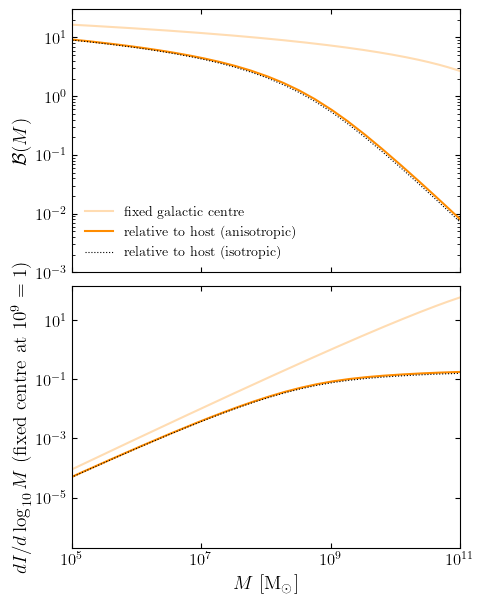

 log M   C_iso   C_aniso   aniso/iso
   5.0   0.547    0.559     1.022
   6.0   0.469    0.483     1.029
   7.0   0.362    0.378     1.043
   8.0   0.217    0.231     1.068
   9.0   0.075    0.083     1.098
  10.0   0.015    0.016     1.113
  11.0   0.003    0.003     1.119
fixed      : I(<1e10)/I(<1e9) = 9.06,  fraction of I(<1e9) from M<1e8 = 0.10


tidal aniso: I(<1e10)/I(<1e9) = 2.78,  fraction of I(<1e9) from M<1e8 = 0.21


tidal iso  : I(<1e10)/I(<1e9) = 2.73,  fraction of I(<1e9) from M<1e8 = 0.21


In [25]:
R_cr  = V0/40
B0_H  = 28.02
Bt    = B_tidal_func(R_cr, B0_H, geometry='aniso')
Bt_i  = B_tidal_func(R_cr, B0_H, geometry='iso')
Mg    = np.logspace(3, 11, 300)
Bf    = B0_H - np.log(Mg)
dndm  = dNdM(Mg, M0, alpha, A)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 7), sharex=True, gridspec_kw={'hspace': 0.05})
for axis in (ax1, ax2):
    axis.set_xscale('log'); axis.set_yscale('log')
    axis.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    axis.set_xlim(1e5, 1e11)

ax1.plot(Mg, Bf,       color='darkorange', alpha=0.3, label=r'fixed galactic centre')
ax1.plot(Mg, Bt(Mg),   color='darkorange',            label=r'relative to host (anisotropic)')
ax1.plot(Mg, Bt_i(Mg), color='k', lw=0.8, ls=':',     label=r'relative to host (isotropic)')
ax1.set_ylabel(r'$\mathcal{B}(M)$'); ax1.set_ylim(1e-3, 30)
ax1.legend(frameon=False, fontsize=10, loc='lower left')

pd_f = np.log(10)*dndm*Mg**3*Bf
pd_t = np.log(10)*dndm*Mg**3*Bt(Mg)
norm = pd_f[np.argmin(abs(Mg-1e9))]
ax2.plot(Mg, pd_f/norm, color='darkorange', alpha=0.3)
ax2.plot(Mg, pd_t/norm, color='darkorange')
ax2.plot(Mg, np.log(10)*dndm*Mg**3*Bt_i(Mg)/norm, color='k', lw=0.8, ls=':')
ax2.set_ylabel(r'$dI/d\log_{10}M$ (fixed centre at $10^9 = 1$)')
ax2.set_xlabel(r'$M$ [M$_{\odot}$]')
plt.show()

Ms_c, C_a = _B_tid_cache[(round(R_cr,4), round(B0_H,4), 'aniso', sigma, V0, 'C')]
_,    C_i = _B_tid_cache[(round(R_cr,4), round(B0_H,4), 'iso',   sigma, V0, 'C')]
print(" log M   C_iso   C_aniso   aniso/iso")
for lm in [5, 6, 7, 8, 9, 10, 11]:
    j = np.argmin(abs(np.log10(Ms_c) - lm))
    print(f"  {lm:4.1f}  {C_i[j]:6.3f}   {C_a[j]:6.3f}    {C_a[j]/C_i[j]:6.3f}")

I = lambda Bfun, Mu: quad(lambda m: dNdM(m, M0, alpha, A)*m**2*Bfun(m), 1e3, Mu, limit=400, points=[1e5,1e7,1e9])[0]
Bfix = lambda m: B0_H - np.log(m)
for name, Bfun in [('fixed', Bfix), ('tidal aniso', Bt), ('tidal iso', Bt_i)]:
    print(f"{name:11s}: I(<1e10)/I(<1e9) = {I(Bfun,1e10)/I(Bfun,1e9):.2f},  "
          f"fraction of I(<1e9) from M<1e8 = {I(Bfun,1e8)/I(Bfun,1e9):.2f}")
